<a href="https://colab.research.google.com/github/RishabhSingh2002-hub/Python-Project/blob/main/Credit_Default_prediction_codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

print("Loading and preparing raw data...")
df = pd.read_excel('credit_default.xlsx')
if 'Customer_ID' in df.columns:
    df = df.drop('Customer_ID', axis=1)

X = df.drop('Default_12M', axis=1)
y = df['Default_12M']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- GLOBAL STATE DICTIONARIES (Fixed!) ---
global_probs = {}
global_thresholds = {}
global_recalls = {}
global_models = {}

# --- CORE TUNING & EVALUATION ENGINE ---
def tune_evaluate_and_store(model, param_grid, model_name):
    print(f"========== Training & Tuning: {model_name} ==========")

    search = RandomizedSearchCV(model, param_grid, n_iter=10, scoring='recall', cv=3, random_state=42, n_jobs=-1)
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    probs = best_model.predict_proba(X_test)[:, 1]

    # Find Best Threshold (Maximizing Recall + Accuracy)
    best_t = 0.5
    best_score = 0
    for t in np.arange(0.1, 0.9, 0.05):
        preds_t = (probs >= t).astype(int)
        combined_score = recall_score(y_test, preds_t, zero_division=0) + accuracy_score(y_test, preds_t)
        if combined_score > best_score:
            best_score = combined_score
            best_t = t

    best_t = round(best_t, 2)
    print(f"Optimal Threshold Fixed At: {best_t}")

    final_preds = (probs >= best_t).astype(int)

    acc = accuracy_score(y_test, final_preds)
    prec = precision_score(y_test, final_preds, zero_division=0)
    rec = recall_score(y_test, final_preds, zero_division=0)
    f1 = f1_score(y_test, final_preds, zero_division=0)

    print(f"[Performance Metrics]")
    print(f"  Accuracy:  {acc:.4f}  |  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}  |  F1-Score:  {f1:.4f}\n")

    # Store globally for Cocktail and Final Scoring
    global_probs[model_name] = probs
    global_thresholds[model_name] = best_t
    global_recalls[model_name] = rec
    global_models[model_name] = best_model # <--- Storing the trained model here!

    cm = confusion_matrix(y_test, final_preds)
    plt.figure(figsize=(4, 2.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
                yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
    plt.title(f"{model_name}")
    plt.show()

Loading and preparing raw data...


========== Training & Tuning: Decision Tree ==========
Optimal Threshold Fixed At: 0.1
[Performance Metrics]
  Accuracy:  0.6817  |  Precision: 0.3147
  Recall:    0.5254  |  F1-Score:  0.3937



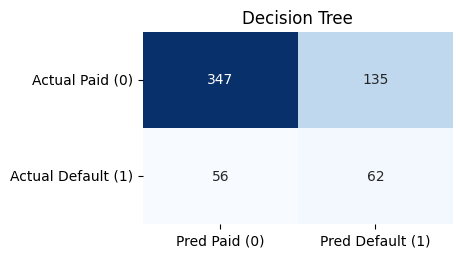

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tune_evaluate_and_store(DecisionTreeClassifier(random_state=42), dt_params, "Decision Tree")

========== Training & Tuning: Random Forest ==========
Optimal Threshold Fixed At: 0.3
[Performance Metrics]
  Accuracy:  0.6250  |  Precision: 0.3136
  Recall:    0.7627  |  F1-Score:  0.4444



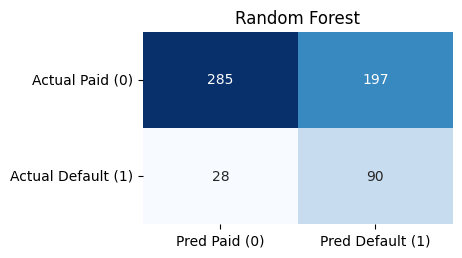

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

tune_evaluate_and_store(RandomForestClassifier(random_state=42), rf_params, "Random Forest")

========== Training & Tuning: Gradient Boosting ==========
Optimal Threshold Fixed At: 0.1
[Performance Metrics]
  Accuracy:  0.6383  |  Precision: 0.3012
  Recall:    0.6356  |  F1-Score:  0.4087



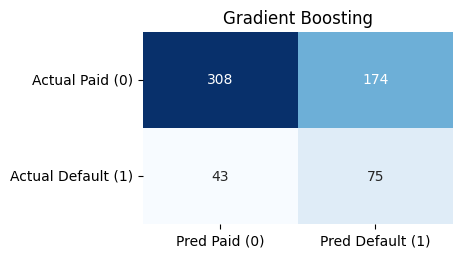

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

tune_evaluate_and_store(GradientBoostingClassifier(random_state=42), gb_params, "Gradient Boosting")

========== Training & Tuning: AdaBoost ==========
Optimal Threshold Fixed At: 0.4
[Performance Metrics]
  Accuracy:  0.6617  |  Precision: 0.3320
  Recall:    0.7119  |  F1-Score:  0.4528



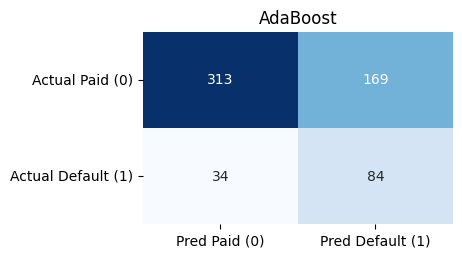

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

tune_evaluate_and_store(AdaBoostClassifier(random_state=42), ada_params, "AdaBoost")

========== Training & Tuning: LightGBM ==========
Optimal Threshold Fixed At: 0.45
[Performance Metrics]
  Accuracy:  0.6633  |  Precision: 0.3372
  Recall:    0.7373  |  F1-Score:  0.4628



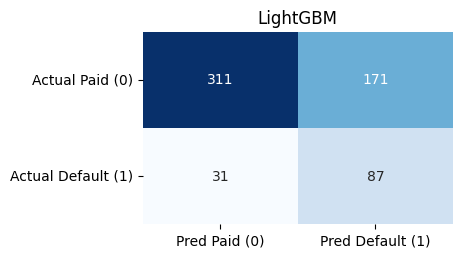

In [ ]:
from lightgbm import LGBMClassifier

lgbm_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [31, 50, 100],
    'class_weight': ['balanced', None]
}

tune_evaluate_and_store(LGBMClassifier(random_state=42, verbose=-1), lgbm_params, "LightGBM")

========== Training & Tuning: XGBoost ==========
Optimal Threshold Fixed At: 0.25
[Performance Metrics]
  Accuracy:  0.6600  |  Precision: 0.3333
  Recall:    0.7288  |  F1-Score:  0.4574



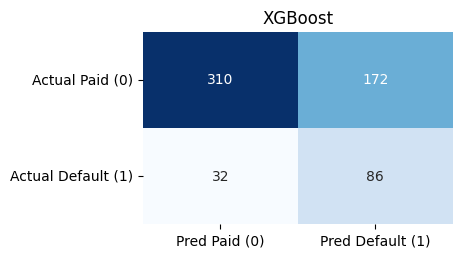

In [ ]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'scale_pos_weight': [1, 2, 3] # Helps with default prediction imbalance
}

tune_evaluate_and_store(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), xgb_params, "XGBoost")

========== BUILDING TIERED RISK COCKTAIL ==========
Top 3 Models by Recall: Random Forest, LightGBM, XGBoost

[Tiered Risk Cocktail Performance]
  Accuracy:  0.6467
  Precision: 0.3259
  Recall:    0.7458
  F1-Score:  0.4536



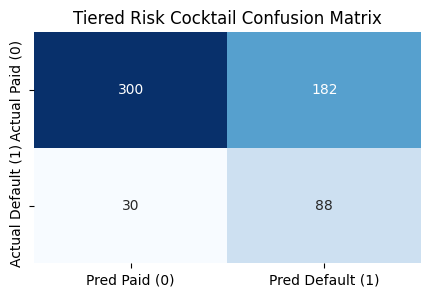

In [ ]:
print("========== BUILDING TIERED RISK COCKTAIL ==========")

# 1. Select Top 3 Models based on Recall Score
sorted_models = sorted(global_recalls.items(), key=lambda x: x[1], reverse=True)
top_3_names = [m[0] for m in sorted_models[:3]]
print(f"Top 3 Models by Recall: {top_3_names[0]}, {top_3_names[1]}, {top_3_names[2]}\n")

# Extract their probabilities and individual tuned thresholds
probs_1, thresh_1 = global_probs[top_3_names[0]], global_thresholds[top_3_names[0]]
probs_2, thresh_2 = global_probs[top_3_names[1]], global_thresholds[top_3_names[1]]
probs_3, thresh_3 = global_probs[top_3_names[2]], global_thresholds[top_3_names[2]]

cocktail_preds = []

# 2. Implement Tiered Risk Voting
for p1, p2, p3 in zip(probs_1, probs_2, probs_3):
    avg_prob = (p1 + p2 + p3) / 3.0

    # TIER 1: Unanimous Low Risk
    if avg_prob < 0.30:
        cocktail_preds.append(0)

    # TIER 2: Unanimous High Risk
    elif avg_prob > 0.70:
        cocktail_preds.append(1)

    # TIER 3: The Gray Area (Execute Threshold Voting)
    else:
        # Each model casts a vote based on its mathematically optimized threshold
        votes = 0
        if p1 >= thresh_1: votes += 1
        if p2 >= thresh_2: votes += 1
        if p3 >= thresh_3: votes += 1

        # Majority rules
        if votes >= 2:
            cocktail_preds.append(1)
        else:
            cocktail_preds.append(0)

cocktail_preds = np.array(cocktail_preds)

# 3. Evaluate Cocktail Performance
c_acc = accuracy_score(y_test, cocktail_preds)
c_prec = precision_score(y_test, cocktail_preds, zero_division=0)
c_rec = recall_score(y_test, cocktail_preds, zero_division=0)
c_f1 = f1_score(y_test, cocktail_preds, zero_division=0)

print(f"[Tiered Risk Cocktail Performance]")
print(f"  Accuracy:  {c_acc:.4f}")
print(f"  Precision: {c_prec:.4f}")
print(f"  Recall:    {c_rec:.4f}")
print(f"  F1-Score:  {c_f1:.4f}\n")

# Store Cocktail Probability (Average) for the ROC curve
global_probs["Tiered Risk Cocktail"] = (probs_1 + probs_2 + probs_3) / 3.0

# 4. Confusion Matrix
cm = confusion_matrix(y_test, cocktail_preds)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
plt.title("Tiered Risk Cocktail Confusion Matrix")
plt.show()

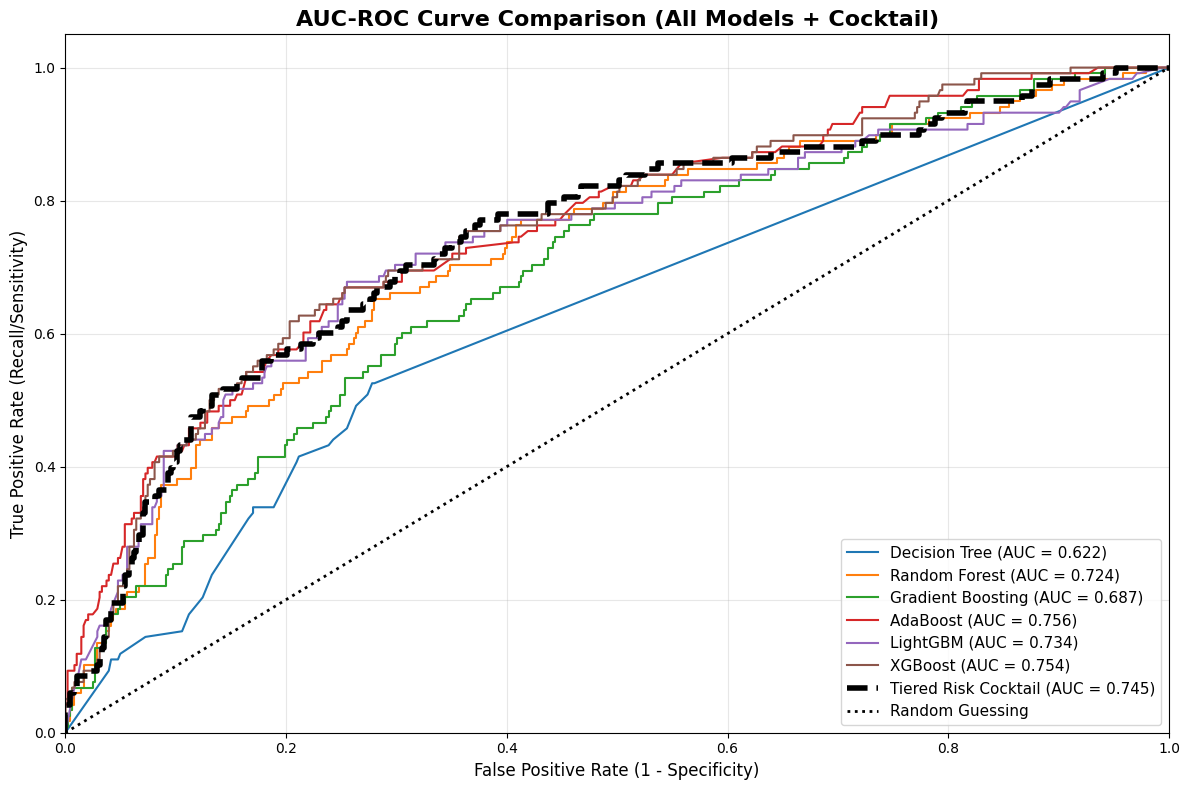

In [ ]:
plt.figure(figsize=(12, 8))

# Loop through all models (including Cocktail) and plot
for name, probs in global_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    # Highlight the Cocktail line
    if "Cocktail" in name:
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=4, linestyle='--', color='black')
    else:
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=1.5)

# Plot random guessing line
plt.plot([0, 1], [0, 1], 'k:', lw=2, label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall/Sensitivity)', fontsize=12)
plt.title('AUC-ROC Curve Comparison (All Models + Cocktail)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import numpy as np

print("--- Generating Final Risk Scores for the Entire Portfolio ---")

# 1. Re-load the original dataset to get Customer_ID
df_original = pd.read_excel('credit_default.xlsx')

if 'Customer_ID' in df_original.columns:
    customer_ids = df_original['Customer_ID']
else:
    customer_ids = df_original.index

# 2. Extract the exact raw features (X_full) that the models were trained on
X_full = df_original.drop(['Default_12M', 'Customer_ID'], axis=1, errors='ignore')

# 3. Dynamically identify the Top 3 models based on Recall
sorted_models = sorted(global_recalls.items(), key=lambda x: x[1], reverse=True)
top_3_names = [m[0] for m in sorted_models[:3]]
print(f"Scoring using Top 3 Models: {top_3_names[0]}, {top_3_names[1]}, {top_3_names[2]}")

# 4. Generate probabilities for the ENTIRE dataset using the saved models
prob_1 = global_models[top_3_names[0]].predict_proba(X_full)[:, 1]
prob_2 = global_models[top_3_names[1]].predict_proba(X_full)[:, 1]
prob_3 = global_models[top_3_names[2]].predict_proba(X_full)[:, 1]

# 5. Blend them into our final Cocktail Risk Probability
final_probabilities = (prob_1 + prob_2 + prob_3) / 3.0

# 6. Apply Tiered Risk Logic to make a hard business decision (0 or 1)
final_decisions = []
thresh_1 = global_thresholds[top_3_names[0]]
thresh_2 = global_thresholds[top_3_names[1]]
thresh_3 = global_thresholds[top_3_names[2]]

for p1, p2, p3, avg_p in zip(prob_1, prob_2, prob_3, final_probabilities):
    if avg_p < 0.30:
        final_decisions.append("Approve (Low Risk)")
    elif avg_p > 0.70:
        final_decisions.append("Reject (High Risk)")
    else:
        # Gray Area: Execute Threshold Voting
        votes = sum([p1 >= thresh_1, p2 >= thresh_2, p3 >= thresh_3])
        if votes >= 2:
            final_decisions.append("Reject (Voting Consensus)")
        else:
            final_decisions.append("Approve (Voting Consensus)")

# 7. Create the final, business-ready scoring table
scored_data = pd.DataFrame({
    'Customer_ID': customer_ids,
    'Probability_of_Default': final_probabilities.round(4),
    'Risk_Score_0_to_100': (final_probabilities * 100).round(1),
    'Final_AI_Decision': final_decisions
})

# Add the historical default status just for comparison if it exists
if 'Default_12M' in df_original.columns:
    scored_data['Historical_Default_Status'] = df_original['Default_12M']

# 8. Save to CSV so you can open it in Excel
filename = 'Final_Customer_Risk_Scores.csv'
scored_data.to_csv(filename, index=False)

print(f"\nSuccess! Scored {len(scored_data)} customers.")
print(f"Data saved to Google Colab files as: {filename}")

# Preview the first 10 rows
display(scored_data.head(10))

--- Generating Final Risk Scores for the Entire Portfolio ---
Scoring using Top 3 Models: Random Forest, LightGBM, XGBoost

Success! Scored 3000 customers.
Data saved to Google Colab files as: Final_Customer_Risk_Scores.csv


,Customer_ID,Probability_of_Default,Risk_Score_0_to_100,Final_AI_Decision,Historical_Default_Status
0,100000,0.5488,54.9,Reject (Voting Consensus),0
1,100001,0.3307,33.1,Approve (Voting Consensus),0
2,100002,0.2735,27.4,Approve (Low Risk),0
3,100003,0.1213,12.1,Approve (Low Risk),0
4,100004,0.3202,32.0,Approve (Voting Consensus),0
5,100005,0.4095,40.9,Reject (Voting Consensus),0
6,100006,0.1324,13.2,Approve (Low Risk),0
7,100007,0.4156,41.6,Reject (Voting Consensus),0
8,100008,0.6293,62.9,Reject (Voting Consensus),1
9,100009,0.5318,53.2,Reject (Voting Consensus),1
